<a href="https://colab.research.google.com/github/AdamHopkinss/DD2365/blob/main/Lab%204%20Fluid-structure%20interaction/Flapping_Wing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Navier-Stokes equations - ALE**
**Johan Hoffman**

Adam Hopkins

# **Abstract**

This short report show an example on how to use FEniCS to solve the Navier-Stokes equations using an ALE method, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://www.kth.se/social/course/DD2365/)

# **About the code**

In [1]:
"""This program is an example file for the course"""
"""DD2365 Advanced Computation in Fluid Mechanics, """
"""KTH Royal Institute of Technology, Stockholm, Sweden."""

# Copyright (C) 2021 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License v2.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

'KTH Royal Institute of Technology, Stockholm, Sweden.'

# **Set up environment**

In [2]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

The Navier-Stokes equations take the form

$\dot u + (u\cdot \nabla)u + \nabla p -\Delta u = f,\quad \nabla \cdot u=0,$

together with suitable initial and boundary conditions.

Here we present a FEniCS implementation of a stabilized space-time Arbitrary Lagrangian-Eulerian (ALE) finite element method to solve the Navier-Stokes equations in 2D. The solution is visualized using FEniCS plotting functions, and is also exported as pvd-files which can be visualized in Paraview.

We seek a finite element approximation $(u,p)\in V\times Q$ such that

$(\dot u + ((u-m)\cdot \nabla)u, v) - (p,\nabla \cdot v) + (\nu \nabla u,\nabla v) + (\nabla \cdot u, q) + SD(u,p;v,q) = (f,v),$

for all test functions $(v,q) \in \hat V\times \hat Q$, where $SD(u,p;v,q)$ is a residual based stabilization term. The mesh velocity is denoted by m.

We present an example of flow past a circular cylinder, for which we compute the force on the surface of the cylinder $\Gamma$ in the direction $\phi$, by Green's formula:

$
F(u,p,\phi)= ~<\nu \nabla u\cdot n-pn, \Phi>_{\Gamma} ~=~(\dot u+(u\cdot \nabla)u, \Phi) + (\nu \nabla u,\nabla \Phi) - (p,\nabla \cdot\Phi)-(f,\Phi),
$

with $\Phi\in V$ a fuinction for which $\Phi\vert _{\Gamma}=\phi$ and $\Phi\vert_{\partial \Omega \setminus \Gamma}=0$. With $\phi=(1,0)$ we get the drag force $F_D$, and with $\phi=(0,1)$ the lift force $F_L$. The drag and lift coefficients are obtained by normalization,

$
c_D = \frac{2F_D}{\rho U^2D}, \quad c_L = \frac{2F_L}{\rho U^2D}
$

where $\rho$ is the density (here $\rho=1$), $U$ the characteristic velocity (here $U=1$), and $D$ the characteristic length scale (here $D$ is the diameter of the cylinder).

The Reynolds number is defined as $Re=\frac{UD}{\nu}$

To read more about how to use similar methods for more complex problems, see e.g.

[Hoffman, Johan, et al. "Towards a parameter-free method for high reynolds number turbulent flow simulation based on adaptive finite element approximation." Computer Methods in Applied Mechanics and Engineering 288 (2015): 60-74.](https://www.sciencedirect.com/science/article/pii/S0045782514004836)


# **Method**

**Define domain and mesh**

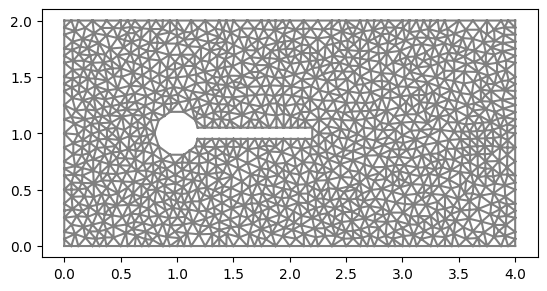

In [3]:
# Define rectangular domain
L = 4
H = 2

# Define circle
xc = 1
yc = 0.5*H
rc = 0.2


# Define subdomains (for boundary conditions)
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], L)

class Lower(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0.0)

class Upper(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], H)

left = Left()
right = Right()
lower = Lower()
upper = Upper()

# Generate mesh (examples with and without a hole in the mesh)
resolution = 32
#mesh = RectangleMesh(Point(0.0, 0.0), Point(L, H), L*resolution, H*resolution)

# Introduce the "wing", a thin long rectangle from the cylinder:
# Define wing:
wing_length = 6*rc    # Approximate wing length
wing_width = 0.1

wing = Rectangle(Point(xc, yc - wing_width / 2),
                 Point(xc + wing_length, yc + wing_width / 2))

# Define original domain (channel - circle)
original_domain = Rectangle(Point(0.0,0.0), Point(L,H)) - Circle(Point(xc,yc),rc)

domain = original_domain - wing   # subtract wing

mesh = generate_mesh(domain, resolution)

# Local mesh refinement (specified by a cell marker)
no_levels = 0
for i in range(0,no_levels):
  cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
  for cell in cells(mesh):
    cell_marker[cell] = False
    p = cell.midpoint()
    if p.distance(Point(xc, yc)) < 1.0:
        cell_marker[cell] = True
  mesh = refine(mesh, cell_marker)

# Define mesh functions (for boundary conditions)
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundaries.set_all(0)
left.mark(boundaries, 1)
right.mark(boundaries, 2)
lower.mark(boundaries, 3)
upper.mark(boundaries, 4)

plt.figure()
plot(mesh)
plt.show()

**Define finite element approximation spaces**

In [4]:
# Generate finite element spaces (for velocity and pressure)
V = VectorFunctionSpace(mesh, "Lagrange", 1)
Q = FunctionSpace(mesh, "Lagrange", 1)

# Define trial and test functions
u = TrialFunction(V)
p = TrialFunction(Q)
v = TestFunction(V)
q = TestFunction(Q)

**Define boundary conditions**

In [5]:
# Define boundary conditions
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], H)

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], L)

class DirichletBoundaryObjects(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()
dbc_objects = DirichletBoundaryObjects()
dbc_objects.mark(boundaries, 5)   # Mark it to compute forces

# Examples of time dependent and stationary inflow conditions
#uin = Expression('4.0*x[1]*(1-x[1])', element = V.sub(0).ufl_element())
#uin = Expression('1.0 + 1.0*fabs(sin(t))', element = V.sub(0).ufl_element(), t=0.0)
uin = 1.0
bcu_in0 = DirichletBC(V.sub(0), uin, dbc_left)
bcu_in1 = DirichletBC(V.sub(1), 0.0, dbc_left)
bcu_upp0 = DirichletBC(V.sub(0), 0.0, dbc_upper)
bcu_upp1 = DirichletBC(V.sub(1), 0.0, dbc_upper)
bcu_low0 = DirichletBC(V.sub(0), 0.0, dbc_lower)
bcu_low1 = DirichletBC(V.sub(1), 0.0, dbc_lower)
bcu_obj0 = DirichletBC(V.sub(0), 0.0, dbc_objects)
bcu_obj1 = DirichletBC(V.sub(1), 0.0, dbc_objects)

pin = Expression('5.0*fabs(sin(t))', element = Q.ufl_element(), t=0.0)
pout = 0.0
#bcp0 = DirichletBC(Q, pin, dbc_left)
bcp1 = DirichletBC(Q, pout, dbc_right)

#bcu = [bcu_in0, bcu_in1, bcu_upp0, bcu_upp1, bcu_low0, bcu_low1, bcu_obj0, bcu_obj1]
bcu = [bcu_in0, bcu_in1, bcu_upp1, bcu_low1, bcu_obj0, bcu_obj1]
bcp = [bcp1]

# Define measure for boundary integration
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

# **Results**

**Define flow parameters**

In [6]:
# Set viscosity
nu = 4.0e-3

**Define method parameters**

In [7]:
# Define iteration functions
# (u0,p0) solution from previous time step
# (u1,p1) linearized solution at present time step
u0 = Function(V)
u1 = Function(V)
p0 = Function(Q)
p1 = Function(Q)


# Define mesh deformation w, mesh velocity = w/dt
amp_y = 0.005     # Note: this is deformation/time
freq = 0.15
t = 0.0
sgn = 0.0
w = Expression((
    "0.0",
    "x[0] < x0 ? 0.0 : "
    "(x[0] <= x1 ? (x[0] - x0)/(x1 - x0) : 1.0) * amp_y * sgn * sin(pi*x[1]/H)"),
               x0=xc + rc,
               x1=xc + rc + wing_length,
               H=H,
               amp_y=amp_y,
               sgn=sgn,
               pi=np.pi,
               element=V.ufl_element())

# Set parameters for nonlinear and lienar solvers
num_nnlin_iter = 5
prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

# Time step length
dt = 0.5*mesh.hmin()

**Define variational problem**

In [8]:
# Define variational problem

# Stabilization parameters
h = CellDiameter(mesh);
u_mag = sqrt(dot(u1,u1))
d1 = 1.0/sqrt((pow(1.0/dt,2.0) + pow(u_mag/h,2.0)))
d2 = h*u_mag

# Mean velocities for trapozoidal time stepping
um = 0.5*(u + u0)
um1 = 0.5*(u1 + u0)

# Momentum variational equation on residual form
Fu = inner((u - u0)/dt + grad(um)*(um1-w/dt), v)*dx - p1*div(v)*dx + nu*inner(grad(um), grad(v))*dx \
    + d1*inner((u - u0)/dt + grad(um)*(um1-w/dt) + grad(p1), grad(v)*(um1-w/dt))*dx + d2*div(um)*div(v)*dx
au = lhs(Fu)
Lu = rhs(Fu)

# Continuity variational equation on residual form
Fp = d1*inner((u1 - u0)/dt + grad(um1)*(um1-w/dt) + grad(p), grad(q))*dx + div(um1)*q*dx
ap = lhs(Fp)
Lp = rhs(Fp)

**Compute force on boundary**

In [9]:
# It proved difficult to compute the lift/drag forces in variational form
# with a moving boundary, So I did it in a more naive way:
# Stress tensor:
n = FacetNormal(mesh)
sigma = -p1*Identity(2) + nu*(grad(u1) + grad(u1).T)
traction = dot(sigma, n)


# Force normalization
D = 2*rc
normalization = -2.0/D

**Set plotting variables and open export files**

In [10]:
# Open files to export solution to Paraview
file_u = File("results-NS/u.pvd")
file_p = File("results-NS/p.pvd")

# Set plot frequency
plot_time = 0
plot_freq = 20

# Force computation data
force_array_lift = np.array(0.0)
force_array_lift = np.delete(force_array_lift, 0)
force_array_drag = np.array(0.0)
force_array_drag = np.delete(force_array_drag, 0)

time = np.array(0.0)
time = np.delete(time, 0)
start_sample_time = 1.0

**Time stepping algorithm**

Time t = 0.032051409397347845


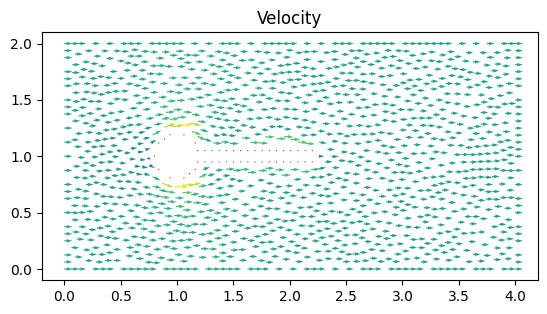

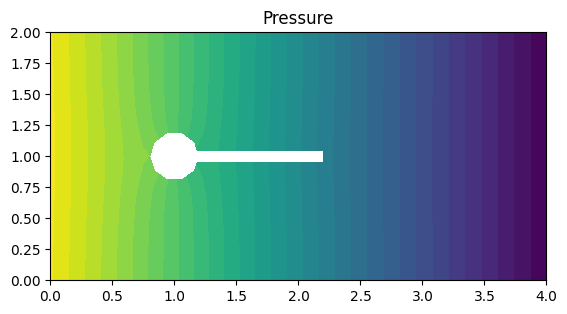

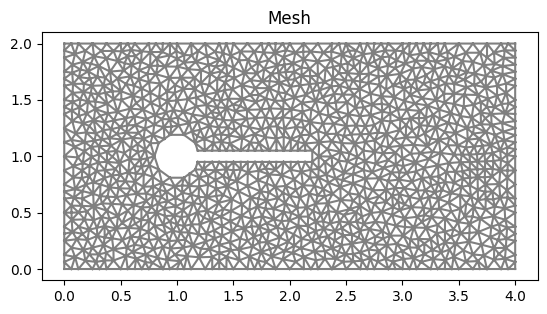

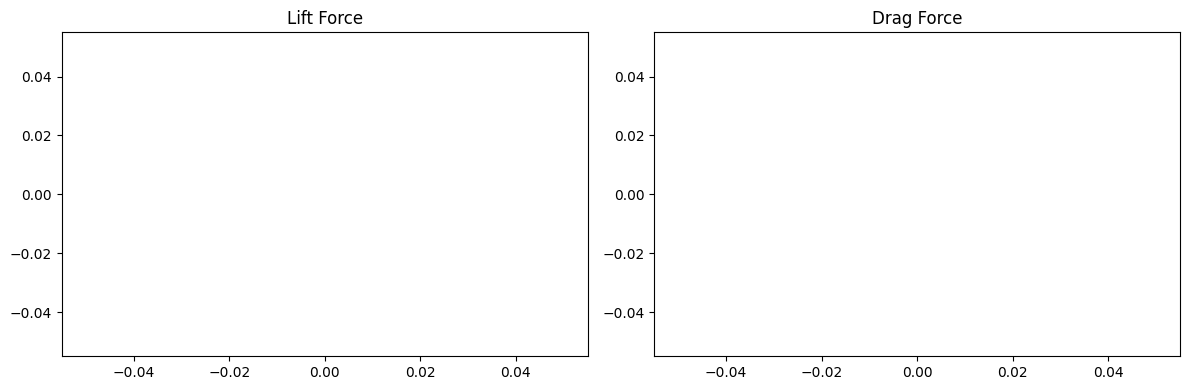

Time t = 1.5064162416753488


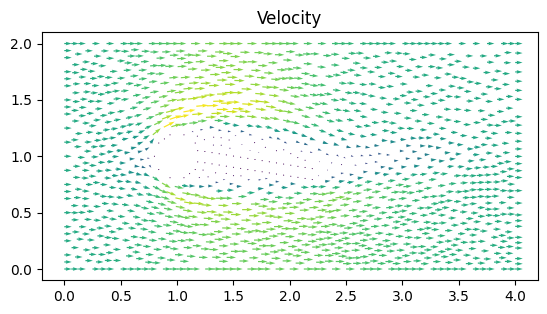

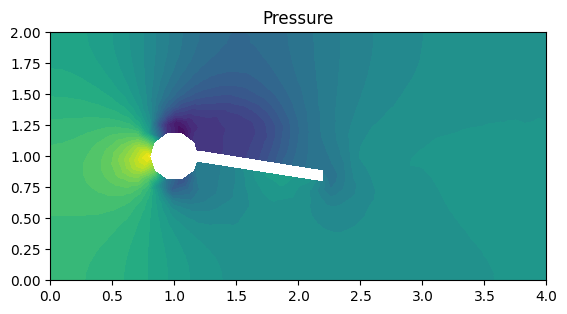

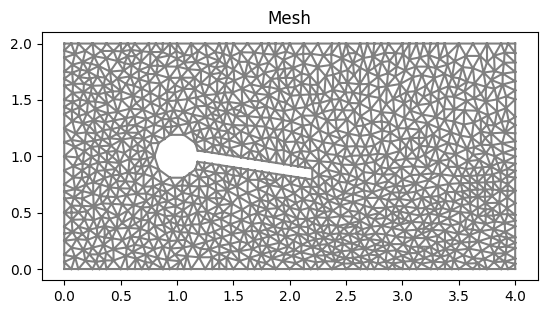

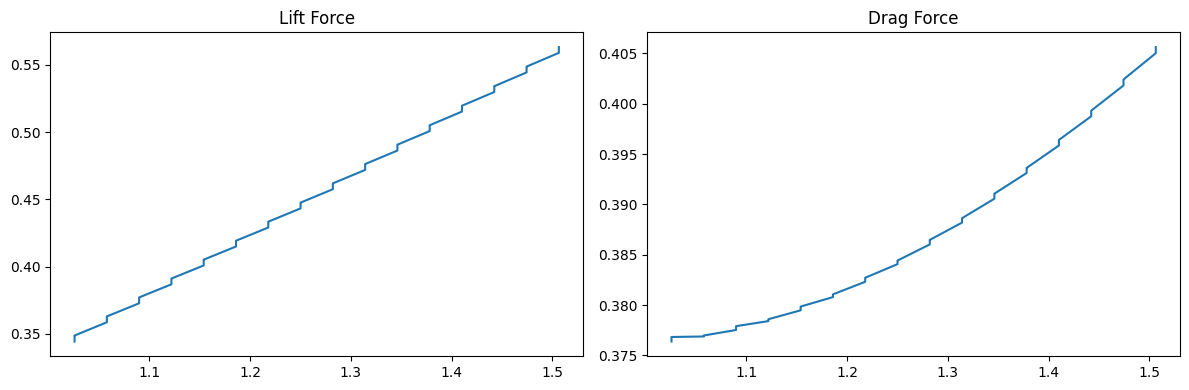

Time t = 3.012832483350691


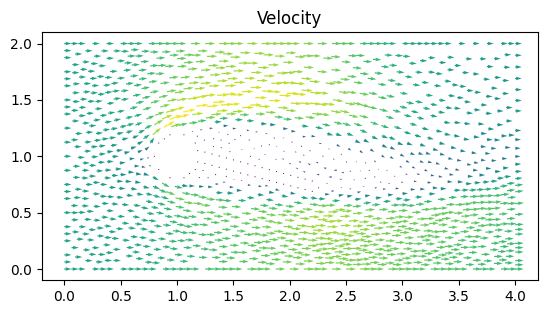

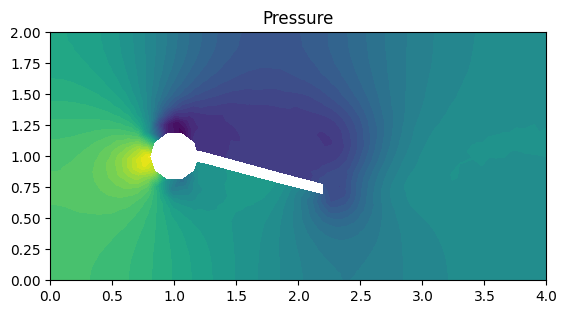

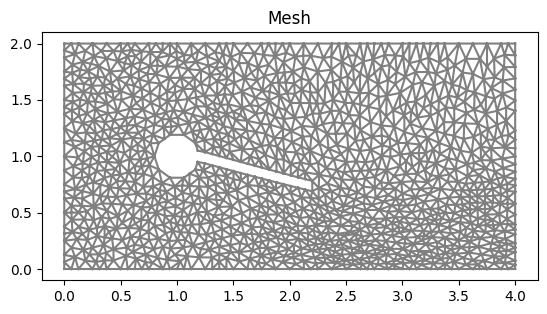

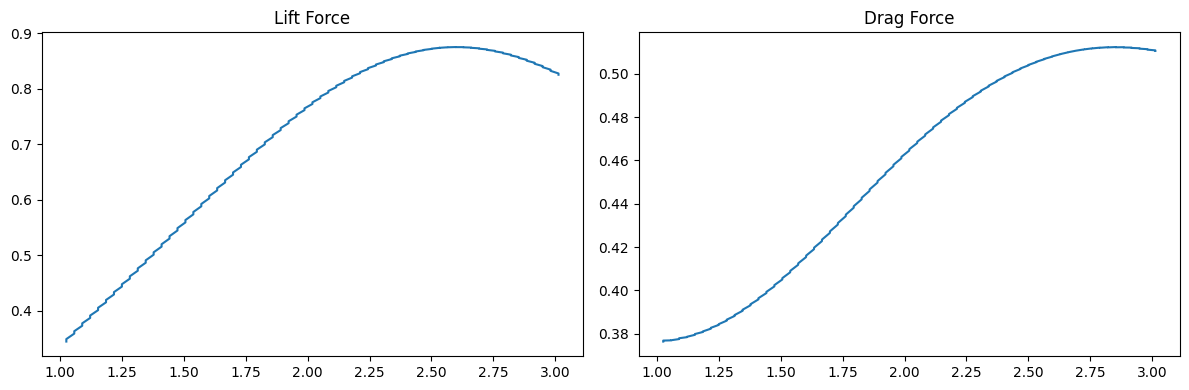

Time t = 4.519248725026037


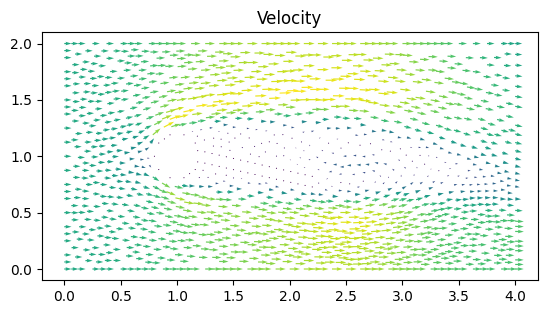

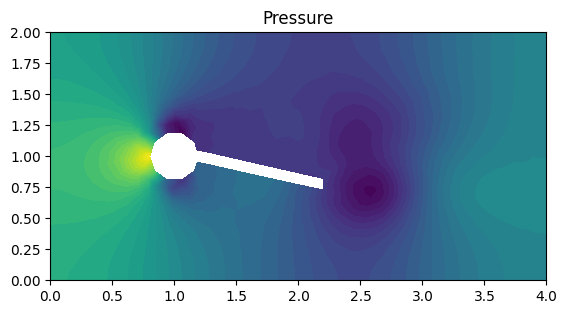

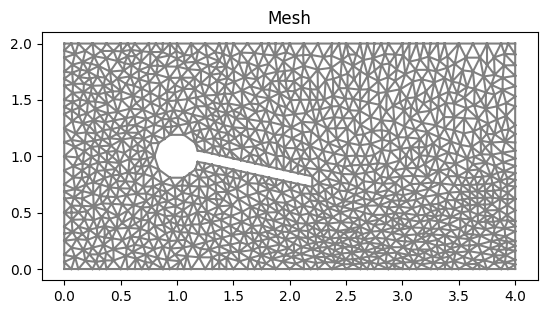

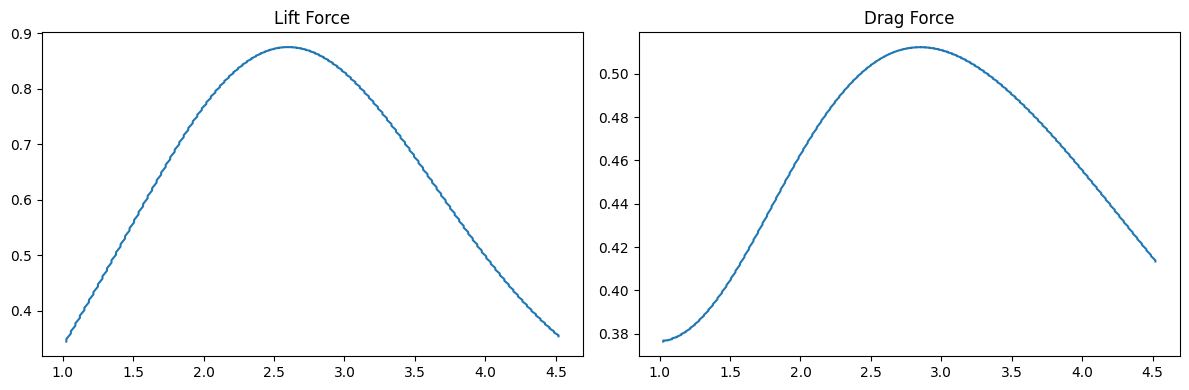

Time t = 6.025664966701396


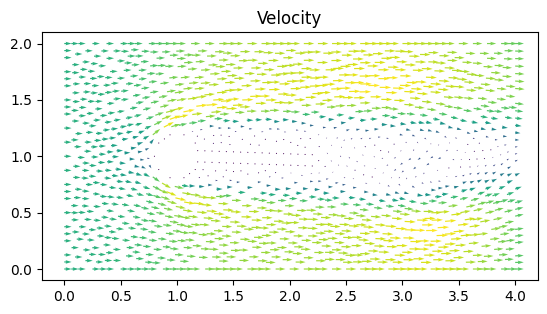

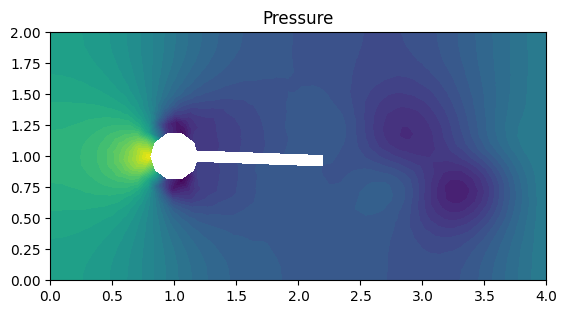

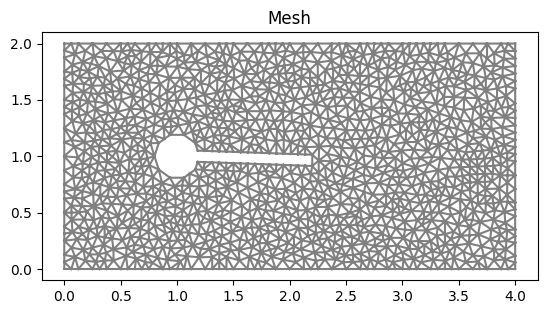

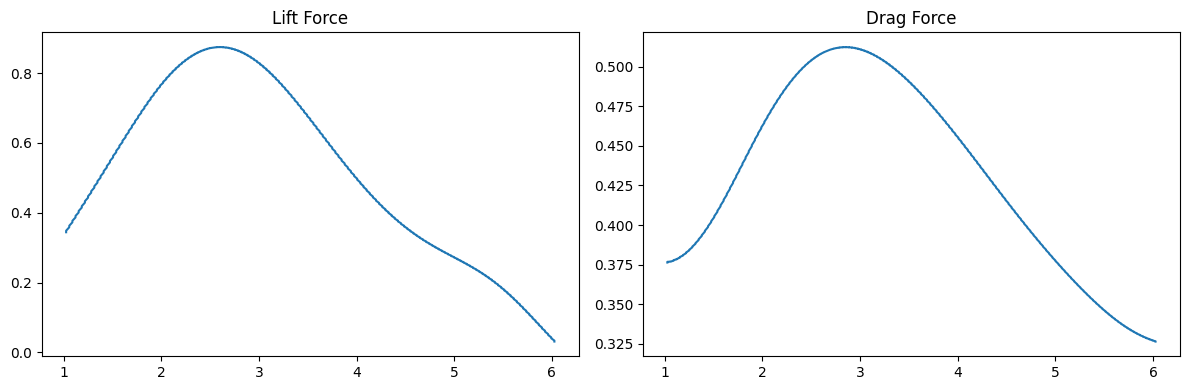

Time t = 7.500029798979408


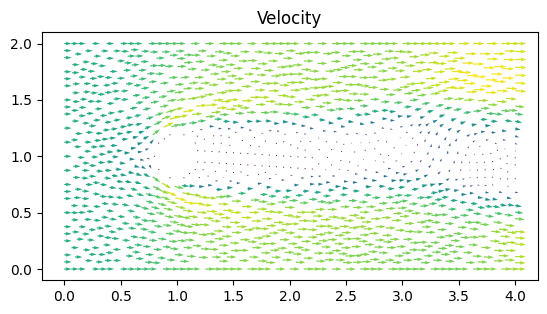

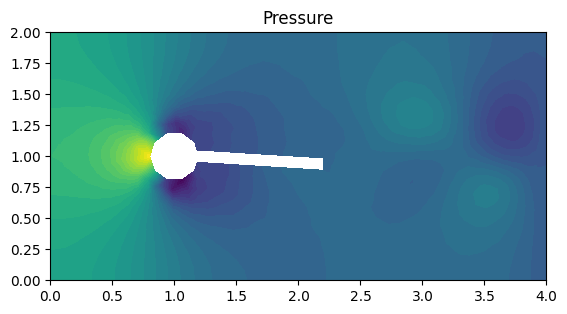

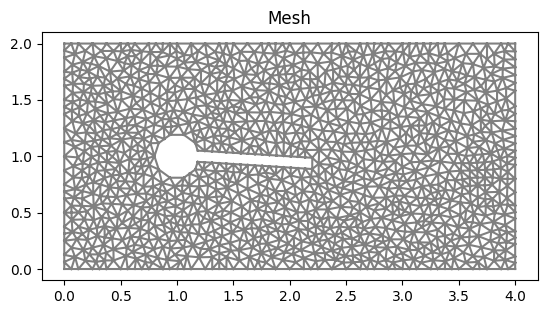

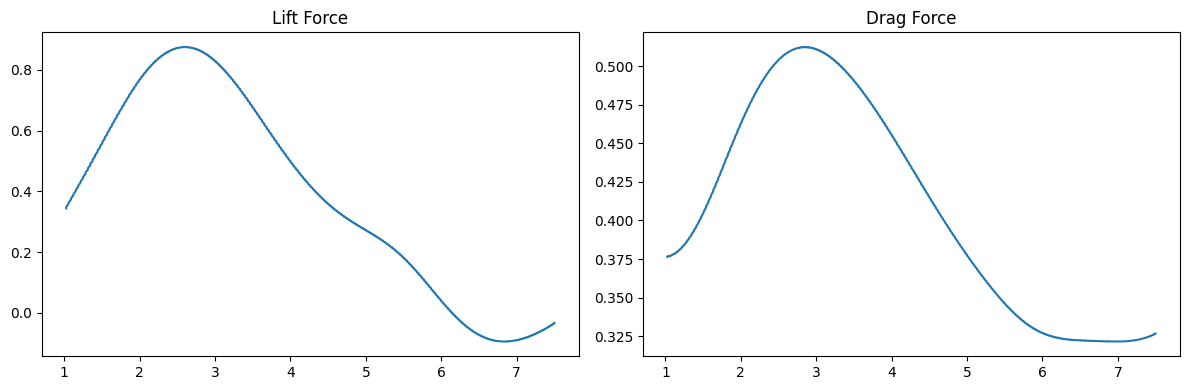

Time t = 9.006446040654739


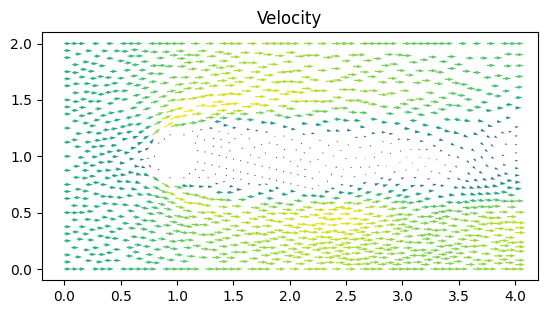

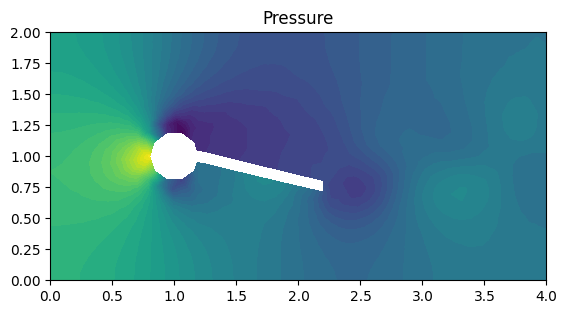

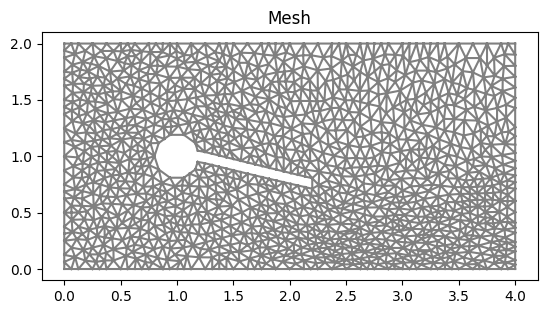

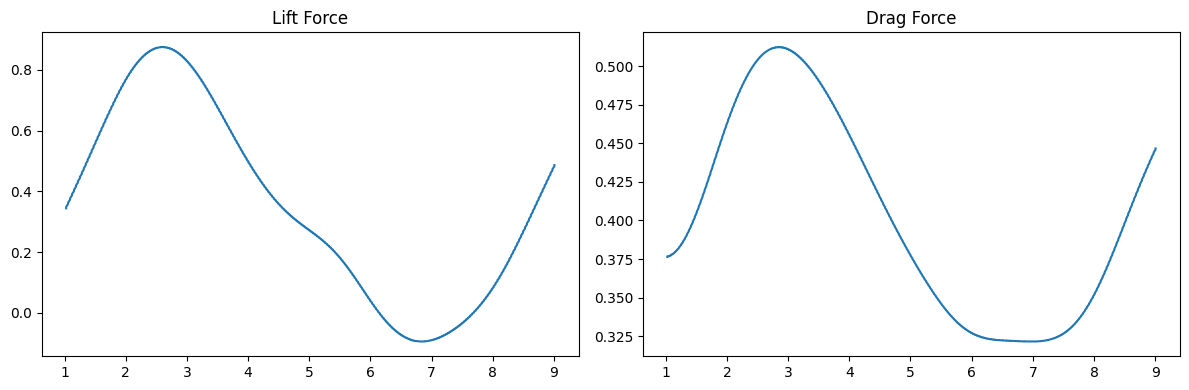

Time t = 10.512862282330056


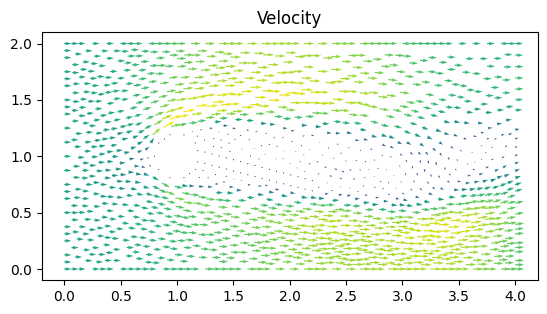

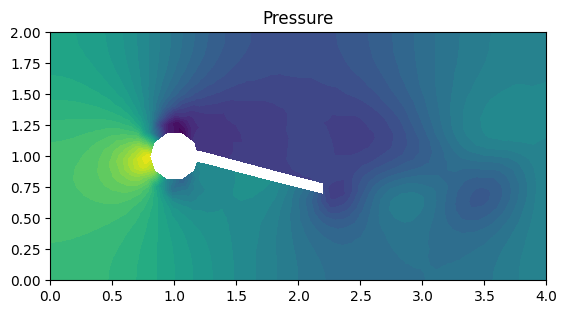

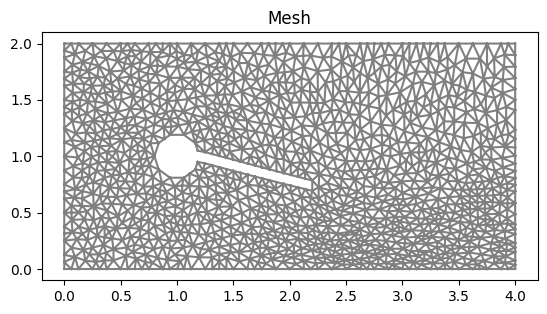

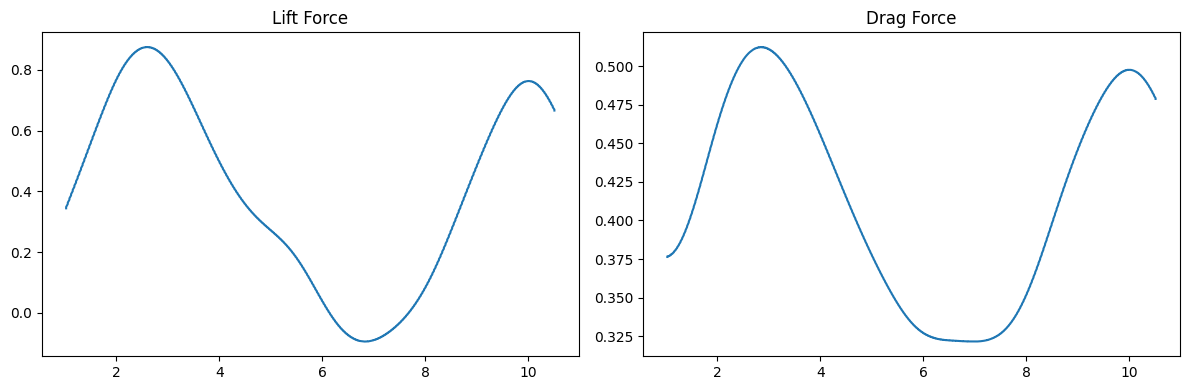

Time t = 12.019278524005374


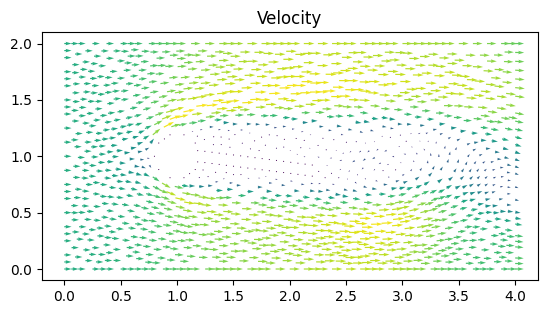

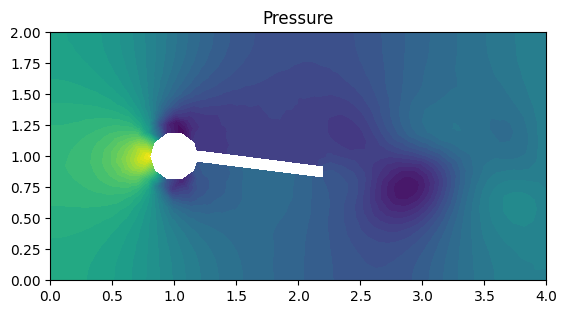

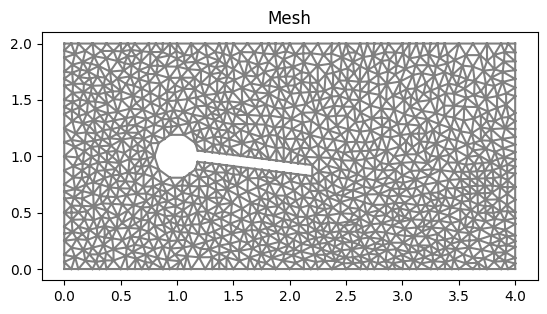

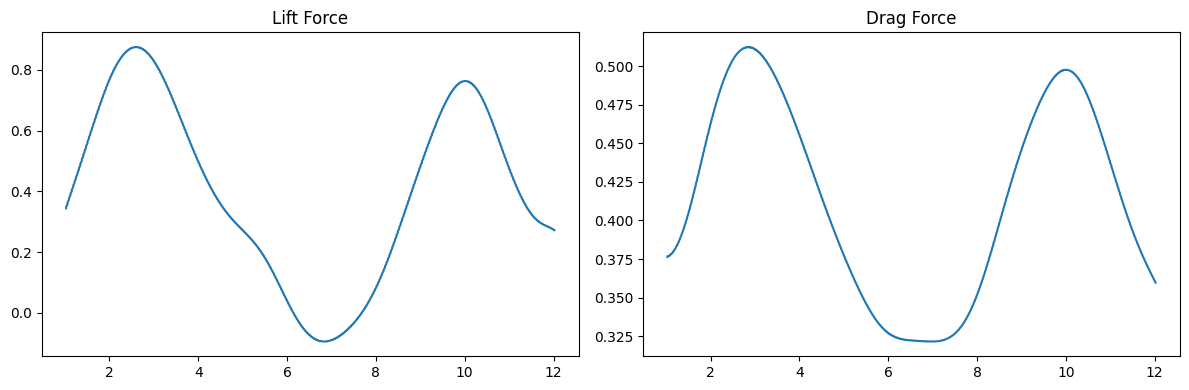

Time t = 13.525694765680692


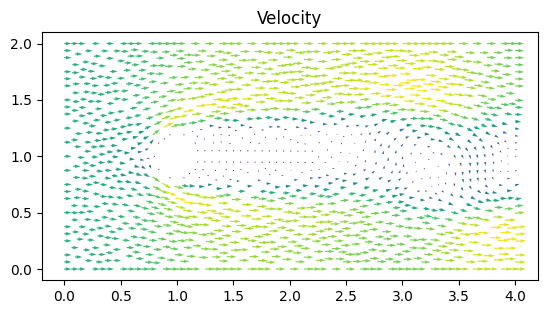

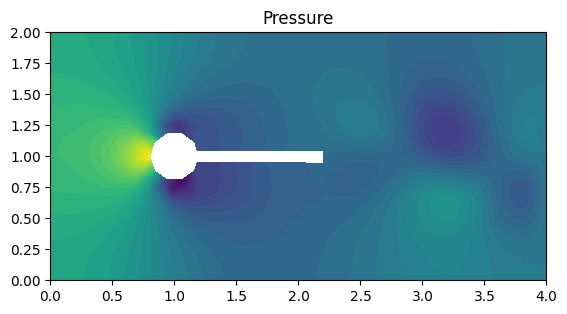

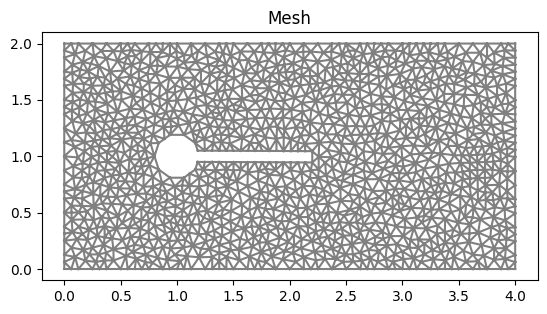

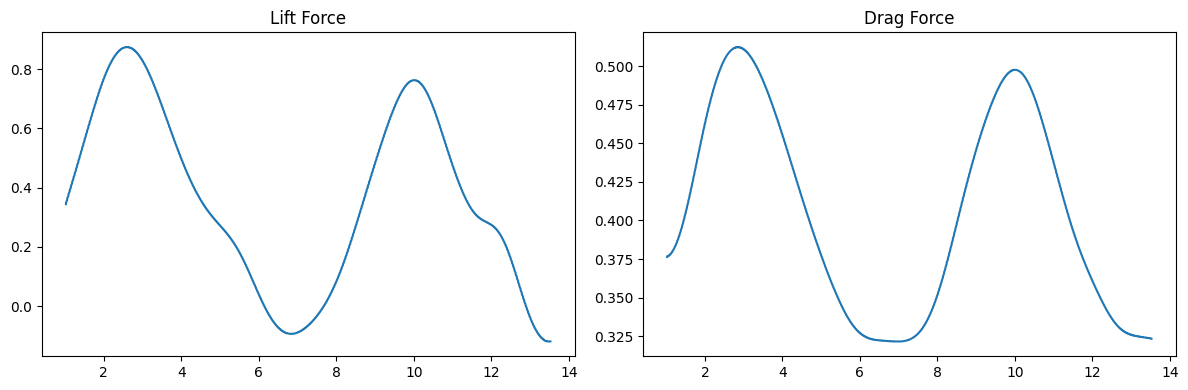

Time t = 15.000059597958662


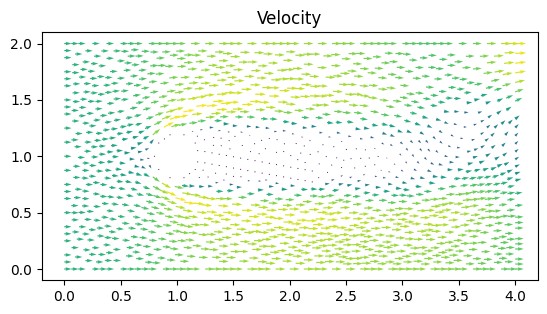

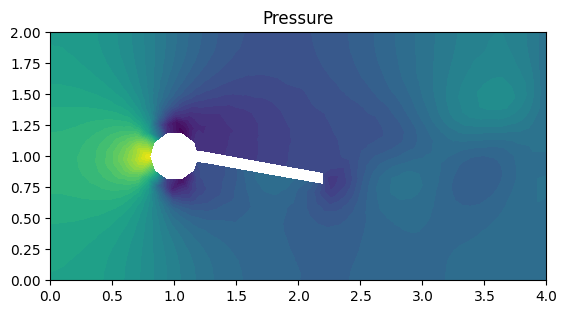

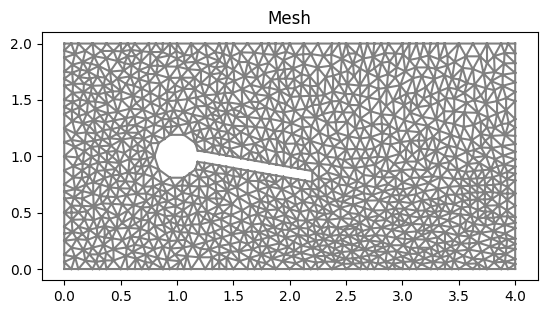

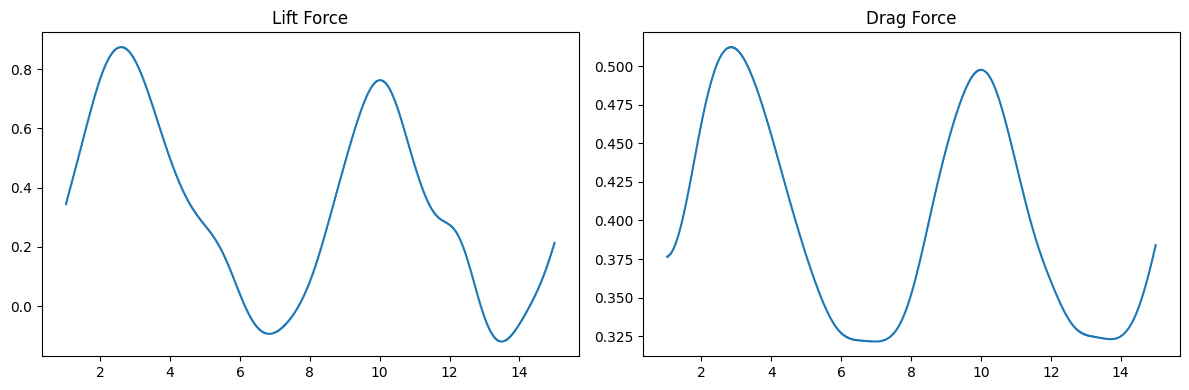

Time t = 16.506475839633982


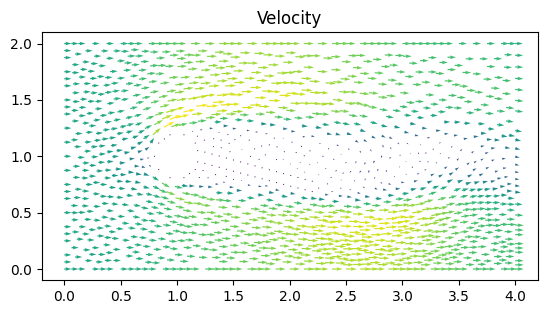

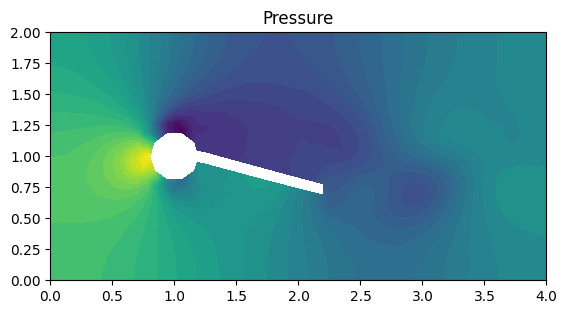

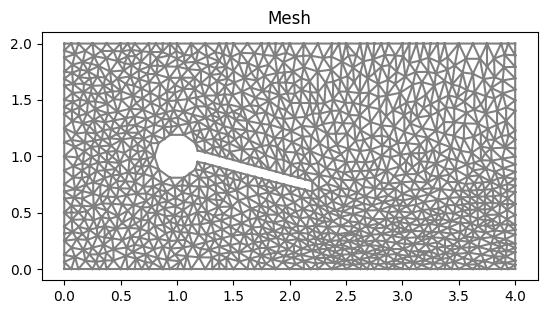

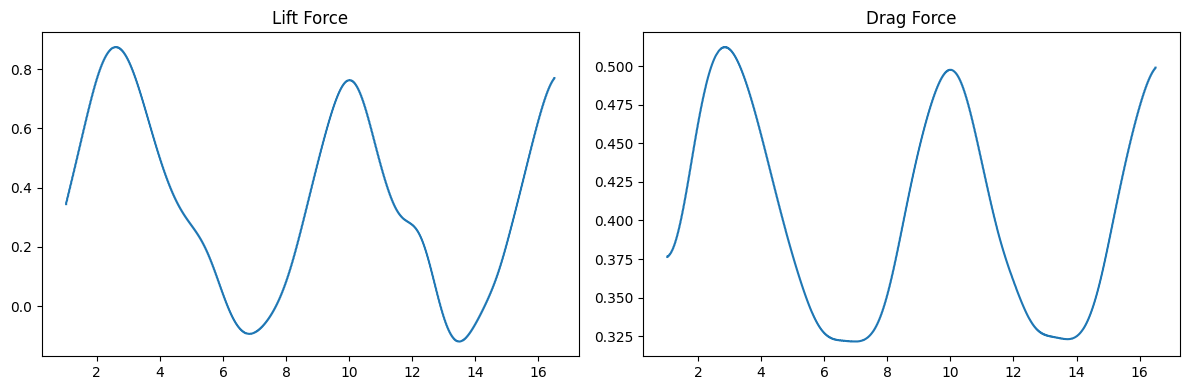

Time t = 18.0128920813093


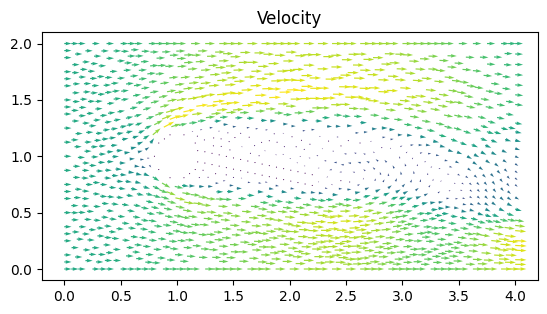

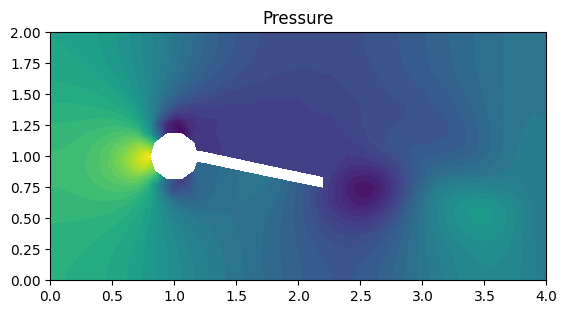

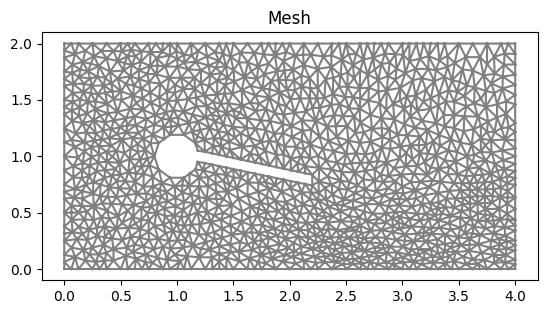

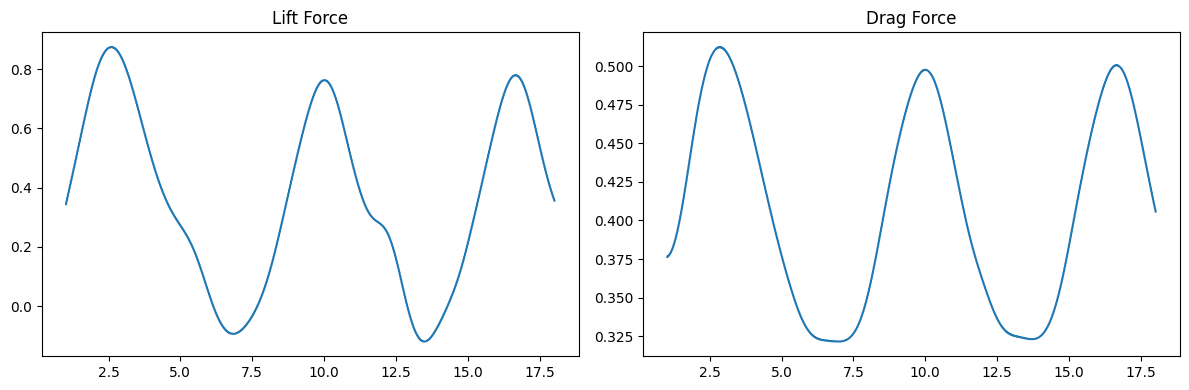

Time t = 19.519308322984617


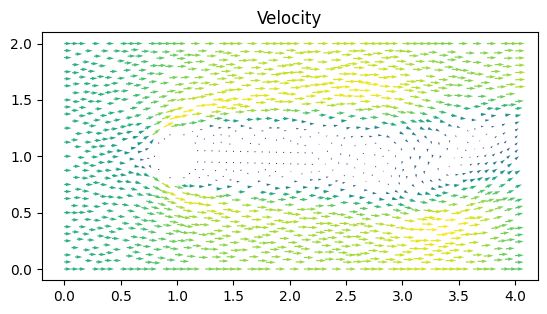

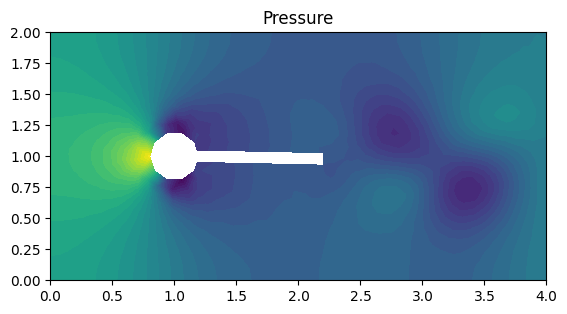

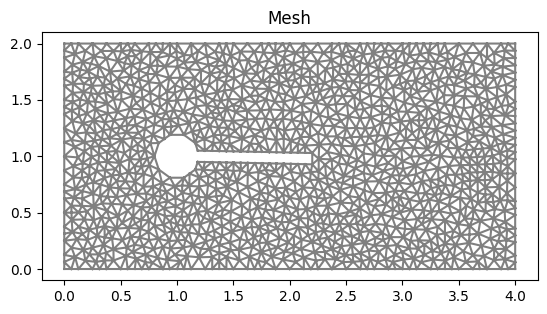

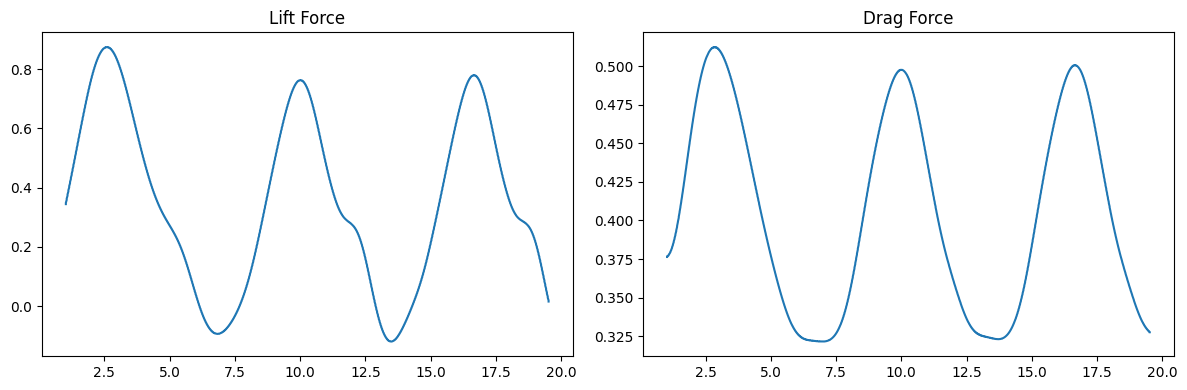

In [ ]:
!rm results-NS/*

# Time stepping
T = 30
t = dt

while t < T + DOLFIN_EPS:

    #s = 'Time t = ' + repr(t)
    #print(s)

    pin.t = t
    #uin.t = t

    w.t = t
    #w.sgn = float(np.sign(np.sin(2 * np.pi * freq * t)))  # Square wave flapping
    w.sgn = -np.sin(2*np.pi * freq * t) - 0.3*np.sin(4*np.pi * freq * t)

    ALE.move(mesh, w)

    # Solve non-linear problem
    k = 0
    while k < num_nnlin_iter:

        # Assemble momentum matrix and vector
        Au = assemble(au)
        bu = assemble(Lu)

        # Compute velocity solution
        [bc.apply(Au, bu) for bc in bcu]
        [bc.apply(u1.vector()) for bc in bcu]
        solve(Au, u1.vector(), bu, "bicgstab", "default")

        # Assemble continuity matrix and vector
        Ap = assemble(ap)
        bp = assemble(Lp)

        # Compute pressure solution
        [bc.apply(Ap, bp) for bc in bcp]
        [bc.apply(p1.vector()) for bc in bcp]
        solve(Ap, p1.vector(), bp, "bicgstab", prec)

        # Compute force
        FL = -assemble(dot(traction, Constant((0.0, 1.0))) * ds(5))
        FD = -assemble(dot(traction, Constant((1.0, 0.0))) * ds(5))
        if (t > start_sample_time):
          force_array_lift = np.append(force_array_lift, FL)
          force_array_drag = np.append(force_array_drag, FD)
          time = np.append(time, t)

        k += 1

    if t > plot_time:

        s = 'Time t = ' + repr(t)
        print(s)

        # Save solution to file
        file_u << u1
        file_p << p1

        # Plot solution
        plt.figure()
        plot(u1, title="Velocity")

        plt.figure()
        plot(p1, title="Pressure")

        plt.figure()
        plot(mesh, title="Mesh")

        plot_time += T/plot_freq

        plt.show()

        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
        # Lift force plot
        axs[0].plot(time, force_array_lift)
        axs[0].set_title("Lift Force")
        # Drag force plot
        axs[1].plot(time, force_array_drag)
        axs[1].set_title("Drag Force")
        plt.tight_layout()
        plt.show()

    # Update time step
    u0.assign(u1)
    t += dt

#!tar -czvf results-NS.tar.gz results-NS
#files.download('results-NS.tar.gz')

In [ ]:
# export to view in paraview

# !tar -czvf results-NS.tar.gz results-NS
# files.download('results-NS.tar.gz')

# **Discussion**

A stabilized finite element method was implemented in FEniCS to solve the Navier-Stokes equations in 2D using an ALE finite element method.

### Flapping Wing

To simulate a flapping wing, I attached a rectangular object to the rear of the cylinder. After testing a few different flapping motions, I settled on a mesh deformation function that only moves the mesh behind the cylinder, thereby simulating the motion of a wing.

The mesh deformation function $w$ satisfies the following conditions:

$$
w_x(x, y) = 0
$$

$$
w_y(x, y, t) =
\begin{cases}
0, & x < x_0 \\
\left( \dfrac{x - x_0}{x_1 - x_0} \right) A \sin\left( \pi \dfrac{y}{H} \right) S(t), & x_0 \le x \le x_1 \\
A \sin\left( \pi \dfrac{y}{H} \right) S(t), & x > x_1
\end{cases}
$$

Here:
* $x_0$ is the $x$-coordinate where the wing starts,

* $x_1$ is the coordinate where the wing ends,

* $A$ is the vertical amplitude of the motion,

* $H$ is the total channel height,

* $S(t)$ is the time-dependent flapping function.

And the y-dependent sine function makes the mesh stationary on the top and bottom boundaries.

The final "flapping" function became:

$$
  S(t) = -\sin(2\pi f t) - 0.3\sin(4\pi f t)
$$

This is a combination of two sine waves that result in a faster downward movement than upward return. The goal of this asymmetry is to generate more lift. The function has a negative sign so that the flapping starts downward, and then moves back to it's original state, and then down again.

#### Computing Drag and Lift Forces

A second challenge was computing the drag and lift forces on the object. Unlike the static cylinder case, we now have a dynamically moving wing, which made the use of variational forms increasingly difficult.

To solve this, I marked the boundaries of both the cylinder and the wing, and computed forces by integrating the Cauchy stress tensor $\sigma$ over the boundary. The tensor is defined as:

\begin{align*}
  \sigma = -pI + \nu(\nabla u + \nabla u^T)
\end{align*}

And the then forces on the boundary of the object $\Gamma_{obj}$ is:

\begin{align*}
  \vec{F} = \int_{\Gamma_{obj}}\sigma \cdot \vec{n} \, ds
\end{align*}

where $\vec{n}$ is the outer pointing unit normal vector on $\Gamma_{obj}$. Then the drag and lift forces are computed by projecting $\vec{F}$ onto the directions of which these forces act, that is, $(1,0)$ for drag, and $(0,1)$ for lift.

#### Maximizing Lift, minimizing Drag

To simplify this problem, that is not changing the flapping function given above, the parameters that are now relevant to the magnitude of the lift and drag forces are the amplitude of which the wing moves, and it's flapping frequency. Preliminary thoughs went something like this:

##### Amplitude $A$
* Higher amplitude $\rightarrow$ stronger downward push $\rightarrow$ more lift
* But also more drag
* There's a sweet spot: too much amplitude $\rightarrow$ flow separation or mesh distortion

##### Frequency $f$
* Higher frequency $\rightarrow$ more momentum transfer to fluid
* But may increase drag
* There should be an optimal frequency

From experimenting with a few different values, I could draw the conclusion that a low flapping frequency of $f \approx 0.15$ produced promising results in terms of lift generation. The effect of the amplitude was a bit more drastic. For instance, setting the amplitude to $A = 0.03$ resulted in a high lift with an averaged value of approximately 3.5, but it also came with a significant drag of about 2.8. On the other hand, reducing the amplitude to $A = 0.01$ yielded a more moderate lift of around 1.0, with a lower drag of approximately 0.7, thus resulting in a lift-to-drag ratio of roughly 1.4.

As expected, more lift comes with more drag, and the choice of parameters must balance these two. It's worth noting that these tests were not extensive, only a few values were evaluated. Therefore, more optimal combinations of frequency and amplitude may exist, and it would be valuable to perform a more systematic parameter check.

Additionally, it's possible that better performance could be achieved by changing the flapping function $S(t)$. For example, introducing motion in the x-direction in addition to some modified vertical motion, which might simulate more realistic wing dynamics, similar to what can be observed in nature, e.g. birds and fish.